# Iris Flower Classification
This notebook demonstrates an end-to-end machine learning workflow to classify Iris species.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load the dataset directly from seaborn's built-in library
iris = sns.load_dataset('iris')
display(iris.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Data Exploration
Let's visualize the relationships between the features.

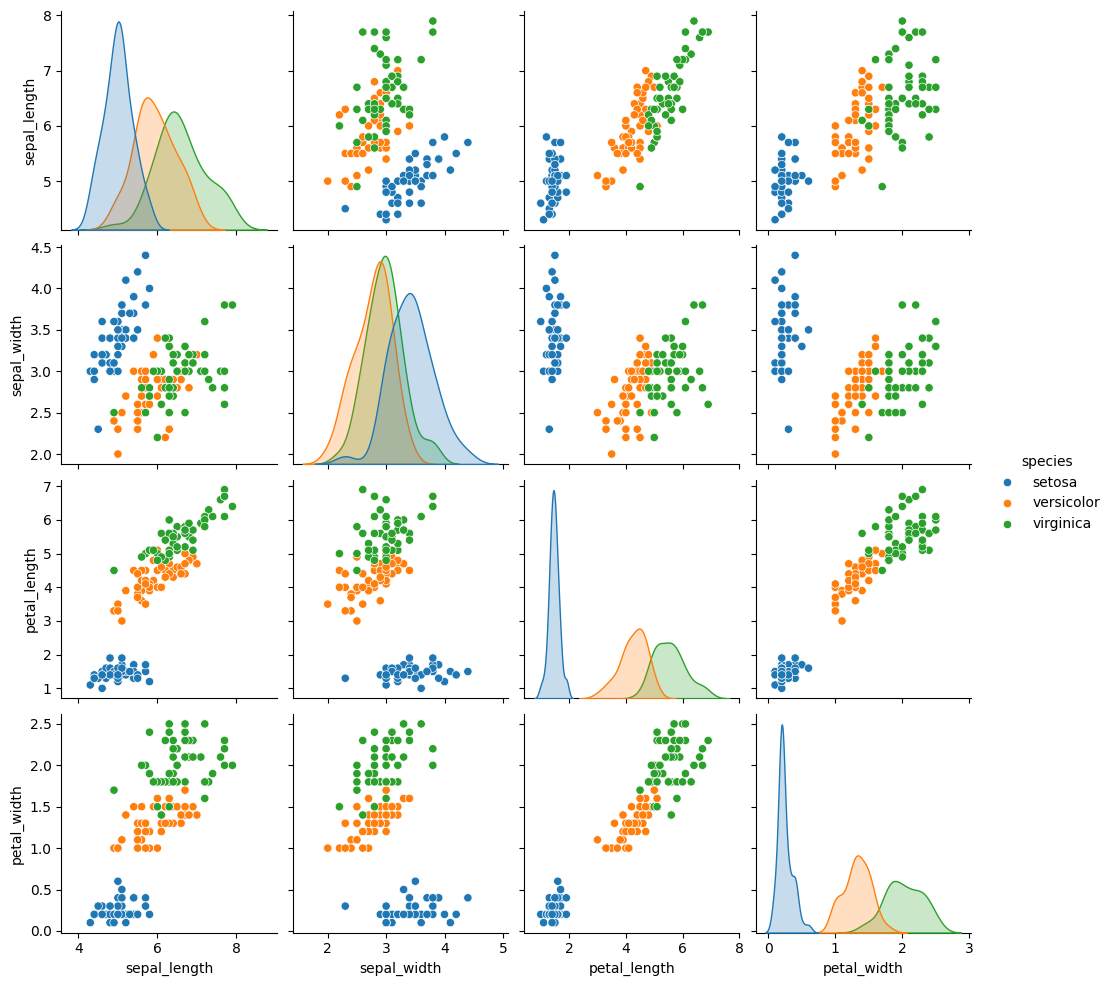

In [2]:
sns.pairplot(iris, hue='species')
plt.show()

### Preprocessing
We will encode the target labels and split the data into training and testing sets.

In [3]:
X = iris.drop('species', axis=1)
y = iris['species']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 120
Testing set size: 30


### Model Training and Evaluation
We'll use a Random Forest Classifier.

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



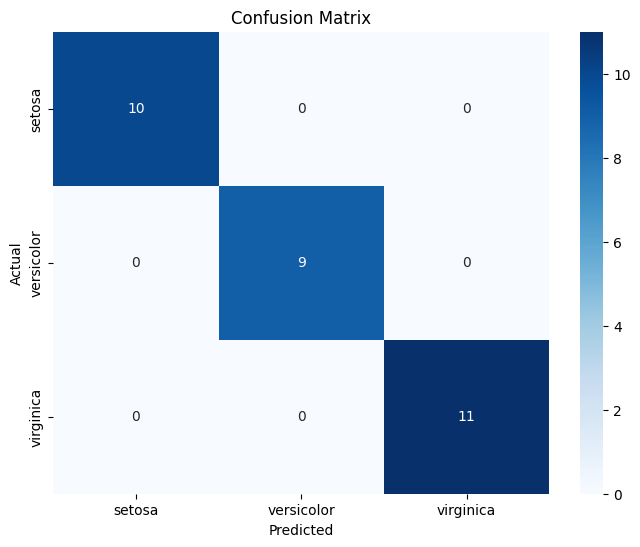

In [4]:
# Initialize and train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Comparison of Multiple Classification Methods

Let's train and evaluate various classification algorithms to compare their performance.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Dictionary to store classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate all classifiers
results = {}
predictions = {}

for name, clf in classifiers.items():
    # Train the model
    clf.fit(X_train, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test)
    predictions[name] = y_pred
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"{name}: Accuracy = {accuracy:.4f}")

print("\n" + "="*50)
print("Summary of All Classification Methods")
print("="*50)

# Sort by accuracy
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
for i, (name, accuracy) in enumerate(sorted_results, 1):
    print(f"{i}. {name}: {accuracy:.4f}")


Logistic Regression: Accuracy = 1.0000
Decision Tree: Accuracy = 1.0000
SVM: Accuracy = 1.0000
K-Nearest Neighbors: Accuracy = 1.0000
Naive Bayes: Accuracy = 1.0000
Gradient Boosting: Accuracy = 1.0000
Random Forest: Accuracy = 1.0000

Summary of All Classification Methods
1. Logistic Regression: 1.0000
2. Decision Tree: 1.0000
3. SVM: 1.0000
4. K-Nearest Neighbors: 1.0000
5. Naive Bayes: 1.0000
6. Gradient Boosting: 1.0000
7. Random Forest: 1.0000


### Detailed Classification Reports

In [6]:
# Display detailed reports for top 3 classifiers
print("Detailed Classification Reports for Top 3 Classifiers:\n")

for i, (name, _) in enumerate(sorted_results[:3]):
    print(f"\n{'='*60}")
    print(f"{i+1}. {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, predictions[name]))


Detailed Classification Reports for Top 3 Classifiers:


1. Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


2. Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


3. SVM
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00

### Confusion Matrices for All Classifiers

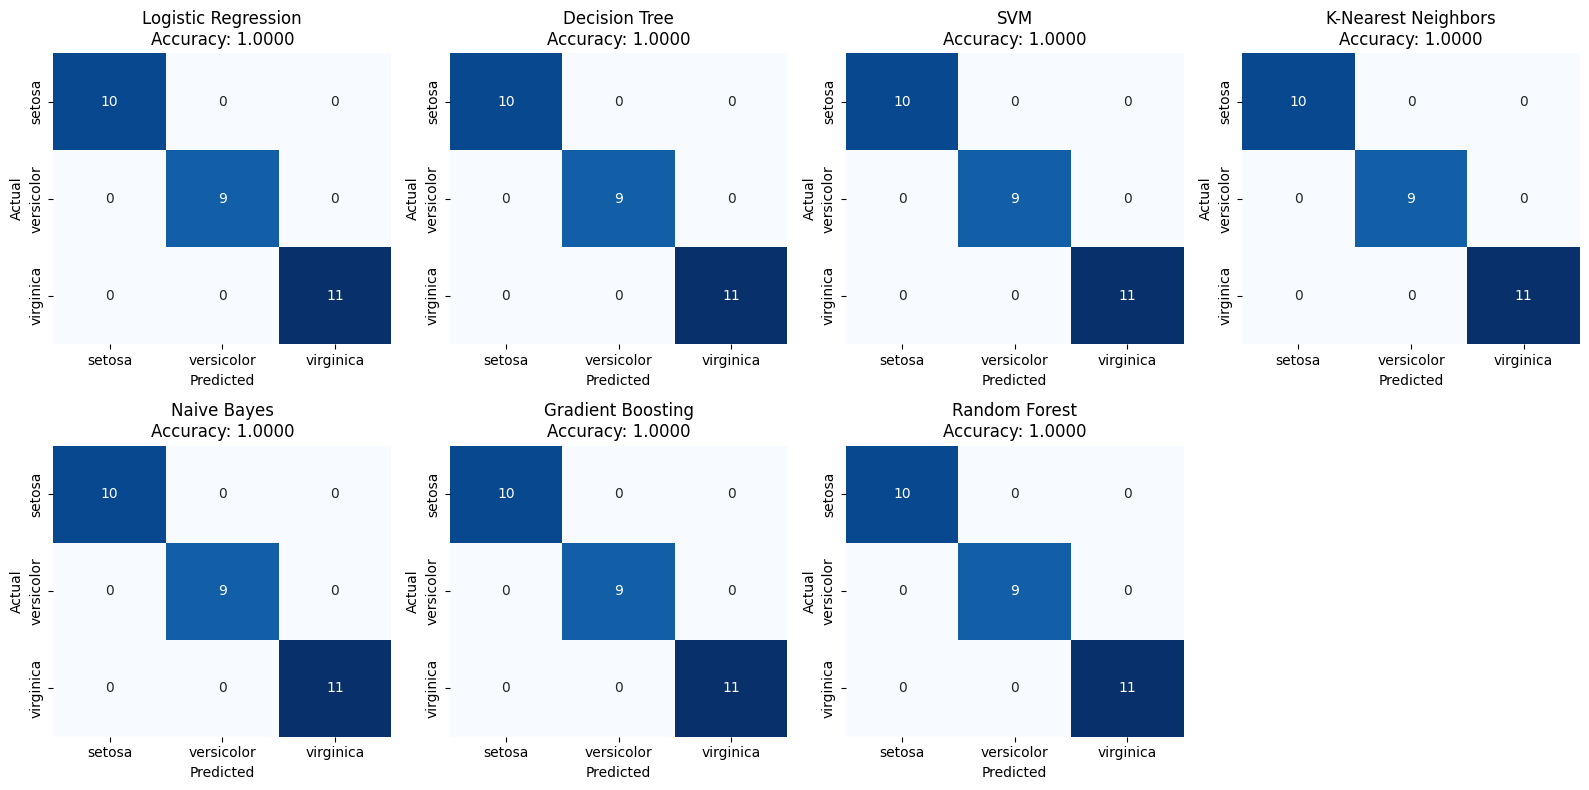

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=iris['species'].unique(), 
                yticklabels=iris['species'].unique(),
                ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name}\nAccuracy: {results[name]:.4f}")
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Hide the last empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


### Accuracy Comparison Visualization

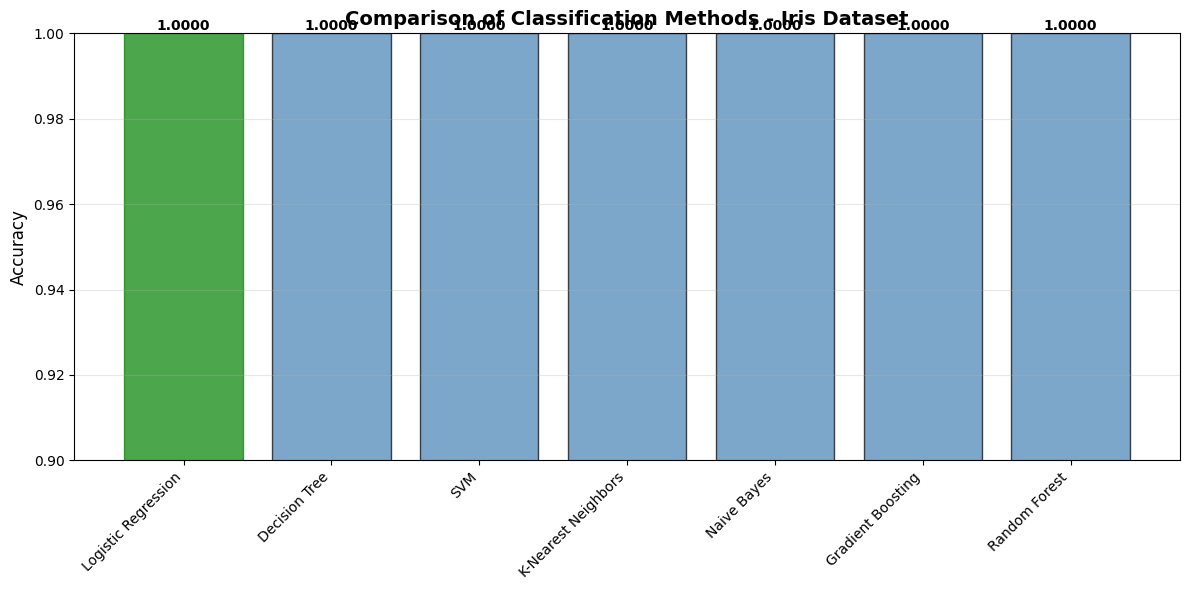

In [8]:
plt.figure(figsize=(12, 6))
names = [name for name, _ in sorted_results]
accuracies = [acc for _, acc in sorted_results]

bars = plt.bar(names, accuracies, color='steelblue', edgecolor='black', alpha=0.7)

# Color the best classifier differently
bars[0].set_color('green')

plt.ylabel('Accuracy', fontsize=12)
plt.title('Comparison of Classification Methods - Iris Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.9, 1.0])
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on top of bars
for bar, accuracy in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{accuracy:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
